/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP - Plant Accuracy: 99.09%, Fertilizer Accuracy: 97.27%


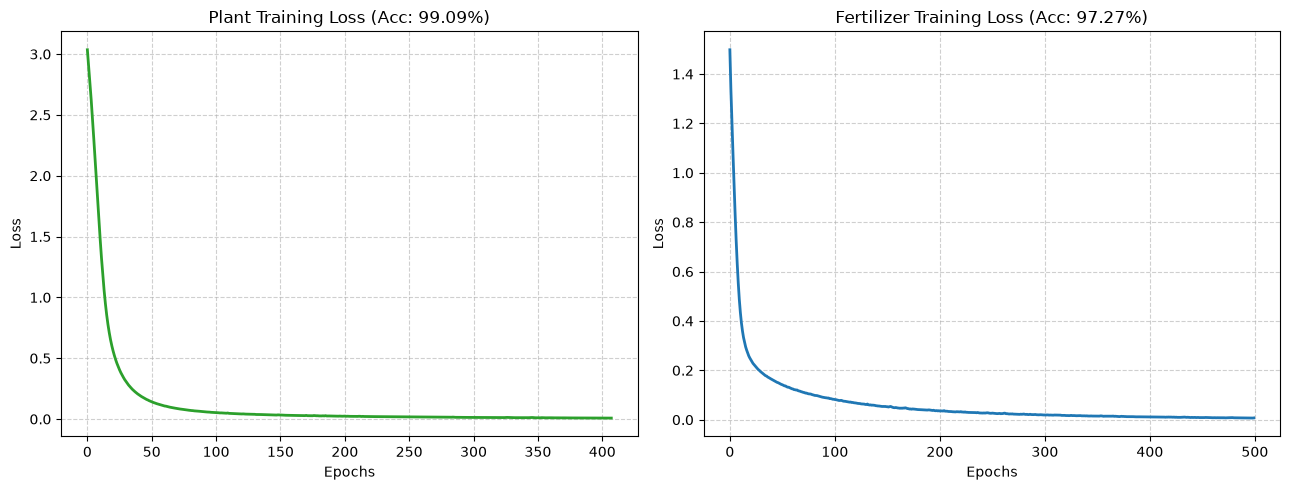

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# --- ข้อมูลที่ 1: ทำนายพืช (Plant.csv) ---
df_plant = pd.read_csv('Plant.csv')
features_plant = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X_p = df_plant[features_plant]
y_p = df_plant['label']
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

scaler_p = StandardScaler()
X_p_train_sc = scaler_p.fit_transform(X_p_train)
X_p_test_sc = scaler_p.transform(X_p_test)

mlp_plant = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp_plant.fit(X_p_train_sc, y_p_train)
acc_plant = accuracy_score(y_p_test, mlp_plant.predict(X_p_test_sc)) * 100

# --- ข้อมูลที่ 2: ทำนายปุ๋ย (Fertilizer.csv) ---
df_fert = pd.read_csv('Fertilizer.csv')
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
cat_cols = ['label']
X_f = df_fert[num_cols + cat_cols]
y_f = df_fert['fertilizer']
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
mlp_fert_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
model_fert = Pipeline([('prep', preprocessor), ('mlp', mlp_fert_model)])
model_fert.fit(X_f_train, y_f_train)
acc_fert = accuracy_score(y_f_test, model_fert.predict(X_f_test)) * 100

print(f"MLP - Plant Accuracy: {acc_plant:.2f}%, Fertilizer Accuracy: {acc_fert:.2f}%")

# --- พล็อตกราฟเปรียบเทียบ Training Loss Curve ของทั้งสองงาน ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(mlp_plant.loss_curve_, color='#2ca02c', linewidth=2)
axes[0].set_title(f'Plant Training Loss (Acc: {acc_plant:.2f}%)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(mlp_fert_model.loss_curve_, color='#1f77b4', linewidth=2)
axes[1].set_title(f'Fertilizer Training Loss (Acc: {acc_fert:.2f}%)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()